# **Assignment -1**       
### **Submitted** **by**- **Tharun** **J** (**jtharun18****@gmail****.com**)

# **Character**-**level** **Tokenization**

In [ ]:
# Character tokenizer
class CharTokenizer:
    def __init__(self, text):
        self.chars = sorted(list(set(text)))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
        self.itos = {i: ch for ch, i in self.stoi.items()}

    def encode(self, text):
        return [self.stoi[ch] for ch in text]

    def decode(self, ids):
        return "".join([self.itos[i] for i in ids])

import requests
url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"
response = requests.get(url)

text = response.text
print(len(text))

char_tokenizer = CharTokenizer(text)
char_tokens = char_tokenizer.encode(text)
print(len(char_tokens))

encoded = char_tokenizer.encode(text)
decoded = char_tokenizer.decode(encoded)

print(encoded)
print(decoded[:500])
print(decoded ==text)


167713
167713
[92, 48, 65, 62, 2, 44, 75, 72, 67, 62, 60, 77, 2, 35, 78, 77, 62, 71, 59, 62, 75, 64, 2, 62, 30, 72, 72, 68, 2, 72, 63, 2, 29, 69, 66, 60, 62, 7, 76, 2, 29, 61, 79, 62, 71, 77, 78, 75, 62, 76, 2, 66, 71, 2, 51, 72, 71, 61, 62, 75, 69, 58, 71, 61, 1, 0, 2, 2, 2, 2, 1, 0, 48, 65, 66, 76, 2, 62, 30, 72, 72, 68, 2, 66, 76, 2, 63, 72, 75, 2, 77, 65, 62, 2, 78, 76, 62, 2, 72, 63, 2, 58, 71, 82, 72, 71, 62, 2, 58, 71, 82, 80, 65, 62, 75, 62, 2, 66, 71, 2, 77, 65, 62, 2, 49, 71, 66, 77, 62, 61, 2, 47, 77, 58, 77, 62, 76, 2, 58, 71, 61, 1, 0, 70, 72, 76, 77, 2, 72, 77, 65, 62, 75, 2, 73, 58, 75, 77, 76, 2, 72, 63, 2, 77, 65, 62, 2, 80, 72, 75, 69, 61, 2, 58, 77, 2, 71, 72, 2, 60, 72, 76, 77, 2, 58, 71, 61, 2, 80, 66, 77, 65, 2, 58, 69, 70, 72, 76, 77, 2, 71, 72, 2, 75, 62, 76, 77, 75, 66, 60, 77, 66, 72, 71, 76, 1, 0, 80, 65, 58, 77, 76, 72, 62, 79, 62, 75, 14, 2, 53, 72, 78, 2, 70, 58, 82, 2, 60, 72, 73, 82, 2, 66, 77, 12, 2, 64, 66, 79, 62, 2, 66, 77, 2, 58, 80, 58, 82, 2, 72, 

In [ ]:
char_vocab_size = len(set(char_tokens))
char_token_count = len(char_tokens)

char_compression = len(text) / char_token_count
char_avg_length = len(text) / char_token_count

print("Character Tokenizer Metrics")
print("Vocabulary Size:", char_vocab_size)
print("Token Count:", char_token_count)
print("Compression Ratio:", char_compression)
print("Average Token Length:", char_avg_length)

Character Tokenizer Metrics
Vocabulary Size: 93
Token Count: 167713
Compression Ratio: 1.0
Average Token Length: 1.0


# **Word**-**level** **Tokenization**

In [ ]:
# Word tokenizer
import requests
class WhitespaceTokenizer:
  def __init__(self):
    pass
  def encode(self, text):
    tokens = []
    current_word = ""

    for ch in text:
      if ch == ' ':
        if current_word != "":
            tokens.append(current_word)
            current_word = ""
        tokens.append(ch)

      elif ch.isalnum():
        current_word += ch

      else:
        if current_word != "":
            tokens.append(current_word)
            current_word = ""
        tokens.append(ch)

    if current_word != "": # This 'if' block needs to be outside the loop
      tokens.append(current_word)

    return tokens

  def decode(self, tokens):
    return "".join(tokens)

  def build_vocab(self, tokens):
    return sorted(list(set(tokens)))

url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"
response = requests.get(url)

text = response.text
print(len(text))

word_tokenizer_manual = WhitespaceTokenizer()
word_tokens_manual = word_tokenizer_manual.encode(text)
print(len(word_tokens_manual))

print(word_tokens_manual[:100])

decoded_manual = word_tokenizer_manual.decode(word_tokens_manual)
print(decoded_manual[:500])
print(decoded_manual == text)



167713
74757
['\ufeff', 'The', ' ', 'Project', ' ', 'Gutenberg', ' ', 'eBook', ' ', 'of', ' ', 'Alice', "'", 's', ' ', 'Adventures', ' ', 'in', ' ', 'Wonderland', '\r', '\n', ' ', ' ', ' ', ' ', '\r', '\n', 'This', ' ', 'eBook', ' ', 'is', ' ', 'for', ' ', 'the', ' ', 'use', ' ', 'of', ' ', 'anyone', ' ', 'anywhere', ' ', 'in', ' ', 'the', ' ', 'United', ' ', 'States', ' ', 'and', '\r', '\n', 'most', ' ', 'other', ' ', 'parts', ' ', 'of', ' ', 'the', ' ', 'world', ' ', 'at', ' ', 'no', ' ', 'cost', ' ', 'and', ' ', 'with', ' ', 'almost', ' ', 'no', ' ', 'restrictions', '\r', '\n', 'whatsoever', '.', ' ', 'You', ' ', 'may', ' ', 'copy', ' ', 'it', ',', ' ', 'give', ' ']
﻿The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License inclu

In [ ]:
word_vocab_size = len(set(word_tokens_manual))
word_token_count = len(word_tokens_manual)

word_compression = len(text) / word_token_count
word_avg_length = len(text) / word_token_count

print("\nWord Tokenizer Metrics")
print("Vocabulary Size:", word_vocab_size)
print("Token Count:", word_token_count)
print("Compression Ratio:", word_compression)
print("Average Token Length:", word_avg_length)


Word Tokenizer Metrics
Vocabulary Size: 3437
Token Count: 74757
Compression Ratio: 2.243442085690972
Average Token Length: 2.243442085690972


In [ ]:
# Word tokenizer using Regrex Version

import re
import requests

class RegexTokenizer:
    def encode(self, text):
        pattern = r'\w+|\s|[^\w\s]'
        tokens = re.findall(pattern, text)
        return tokens

    def decode(self, tokens):
        return "".join(tokens)

url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"
response = requests.get(url)

text = response.text
print(len(text))

word_tokenizer_regex = RegexTokenizer()
word_tokens_regex = word_tokenizer_regex.encode(text)
print(len(word_tokens_regex))
print(len(word_tokens_manual))
print(len(word_tokens_regex))
print(len(word_tokens_manual)==(word_tokens_regex))

print(len(word_tokens_manual))

print(word_tokens_regex[:100])

decoded_regex = word_tokenizer_regex.decode(word_tokens_regex)
print(decoded_regex[:500])
print(decoded_regex == text)


167713
74329
74757
74329
False
74757
['\ufeff', 'The', ' ', 'Project', ' ', 'Gutenberg', ' ', 'eBook', ' ', 'of', ' ', 'Alice', "'", 's', ' ', 'Adventures', ' ', 'in', ' ', 'Wonderland', '\r', '\n', ' ', ' ', ' ', ' ', '\r', '\n', 'This', ' ', 'eBook', ' ', 'is', ' ', 'for', ' ', 'the', ' ', 'use', ' ', 'of', ' ', 'anyone', ' ', 'anywhere', ' ', 'in', ' ', 'the', ' ', 'United', ' ', 'States', ' ', 'and', '\r', '\n', 'most', ' ', 'other', ' ', 'parts', ' ', 'of', ' ', 'the', ' ', 'world', ' ', 'at', ' ', 'no', ' ', 'cost', ' ', 'and', ' ', 'with', ' ', 'almost', ' ', 'no', ' ', 'restrictions', '\r', '\n', 'whatsoever', '.', ' ', 'You', ' ', 'may', ' ', 'copy', ' ', 'it', ',', ' ', 'give', ' ']
﻿The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project

#**BPE**-**level** **Tokenization** **using GPT-2 TikTokenizer**

In [ ]:
# BPE tokenization using GPT-2 tiktokenizer

import requests

!pip install tiktokenizer
import tiktoken

enc = tiktoken.get_encoding("gpt2")

url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"
response = requests.get(url)

text = response.text
print(len(text))

gpt_tokens = enc.encode(text)
gpt_vocab_size = enc.n_vocab
gpt_token_count = len(gpt_tokens)

gpt_compression = len(text) / gpt_token_count
gpt_avg_length = len(text) / gpt_token_count

print("GPT-2 BPE Metrics")
print("Vocabulary Size:", gpt_vocab_size)
print("Token Count:", gpt_token_count)
print("Compression Ratio:", gpt_compression)
print("Average Token Length:", gpt_avg_length)

167713
GPT-2 BPE Metrics
Vocabulary Size: 50257
Token Count: 52951
Compression Ratio: 3.1673245075635967
Average Token Length: 3.1673245075635967


# **Bar Graph for comparission**

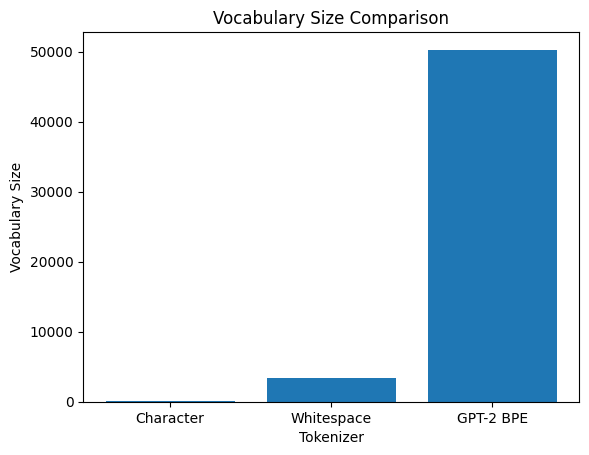

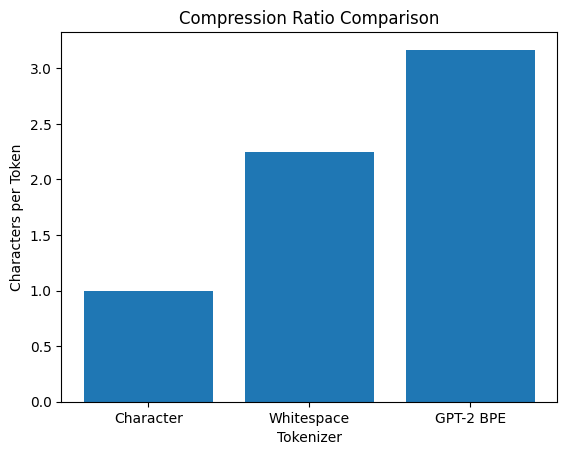

In [ ]:
# comparision plot

import matplotlib.pyplot as plt

tokenizers = ["Character", "Whitespace", "GPT-2 BPE"]

vocab_sizes = [char_vocab_size, word_vocab_size, gpt_vocab_size]
compression_ratios = [char_compression, word_compression, gpt_compression]

# Vocabulary Size Chart
plt.figure()
plt.bar(tokenizers, vocab_sizes)
plt.title("Vocabulary Size Comparison")
plt.xlabel("Tokenizer")
plt.ylabel("Vocabulary Size")
plt.show()

# Compression Ratio Chart
plt.figure()
plt.bar(tokenizers, compression_ratios)
plt.title("Compression Ratio Comparison")
plt.xlabel("Tokenizer")
plt.ylabel("Characters per Token")
plt.show()

## **Reason for this trend?**

Character-level tokenisation has a tiny vocabulary but produces enormously long token sequences because each character becomes a token. This raises computational costs since transformer attention scales quadratically with sequence length. Although word-level tokenisation shortens sequences, it increases vocabulary and may cause out-of-vocabulary problems. This trade-off is balanced by subword tokenisation like GPT-2 BPE, which effectively represents common word fragments while utilising a reasonably big vocabulary. This reduces sequence length without requiring an extremely large vocabulary. According to information theory, character tokens have low entropy, word tokens have large entropy, and subword tokens effectively balance the two.

# **Section 2- Model Parameters : Inference Memory Architecture**

In [ ]:
# GPT-2 configuration values

vocab_size = 50257
sequence_length = 1024
batch_size = 1

models = {
    "Small":  {"layers": 12, "d_model": 768,  "heads": 12, "d_ff": 3072},
    "Medium": {"layers": 24, "d_model": 1024, "heads": 16, "d_ff": 4096},
    "Large":  {"layers": 36, "d_model": 1280, "heads": 20, "d_ff": 5120}
}

In [ ]:
for name, config in models.items():
    print(name, config)

Small {'layers': 12, 'd_model': 768, 'heads': 12, 'd_ff': 3072}
Medium {'layers': 24, 'd_model': 1024, 'heads': 16, 'd_ff': 4096}
Large {'layers': 36, 'd_model': 1280, 'heads': 20, 'd_ff': 5120}


In [ ]:
import pandas as pd

table = {}

for name, config in models.items():

    layers = config["layers"]
    d_model = config["d_model"]
    d_ff = config["d_ff"]

    token_embeddings = vocab_size * d_model
    positional_embeddings = sequence_length * d_model

    attn_qkv = 3 * d_model * d_model
    attn_out = d_model * d_model
    mlp_up = d_model * d_ff
    mlp_down = d_ff * d_model
    layernorm = 4 * d_model

    per_layer = attn_qkv + attn_out + mlp_up + mlp_down + layernorm
    all_layers = per_layer * layers

    final_ln = 2 * d_model

    total_params = token_embeddings + positional_embeddings + all_layers + final_ln

    fp32 = (total_params * 4) / (1024**2)
    fp16 = (total_params * 2) / (1024**2)

    table[name] = {
        "Token Embeddings": token_embeddings,
        "Positional Embeddings": positional_embeddings,
        "Attention QKV": attn_qkv,
        "Attention Out": attn_out,
        "MLP Up": mlp_up,
        "MLP Down": mlp_down,
        "LayerNorms": layernorm,
        "Total Per Layer": per_layer,
        "All Layers": all_layers,
        "Total Params": total_params,
        "FP32 Memory (MB)": fp32,
        "FP16 Memory (MB)": fp16
    }
pd.options.display.float_format = '{:,.0f}'.format
df = pd.DataFrame(table)

df

,Small,Medium,Large
Token Embeddings,"38,597,376","51,463,168","64,328,960"
Positional Embeddings,"786,432","1,048,576","1,310,720"
Attention QKV,"1,769,472","3,145,728","4,915,200"
Attention Out,"589,824","1,048,576","1,638,400"
MLP Up,"2,359,296","4,194,304","6,553,600"
MLP Down,"2,359,296","4,194,304","6,553,600"
LayerNorms,"3,072","4,096","5,120"
Total Per Layer,"7,080,960","12,587,008","19,665,920"
All Layers,"84,971,520","302,088,192","707,973,120"
Total Params,"124,356,864","354,601,984","773,615,360"


In [ ]:
# function to convert tensor size to memory

def tensor_memory(elements, bytes_per_element=4):

    bytes_used = elements * bytes_per_element

    mb = bytes_used / (1024**2)

    return mb

In [ ]:
# activation memory for input embeddings (GPT-2 Small) for FP32

B = 1
T = 1024
d_model = 768
L=12
d_ff=3072

embedding_elements = B * T * d_model
embedding_memory = tensor_memory(embedding_elements)
attention_elements = B * L * T * T
attention_memory = tensor_memory(attention_elements)
qkv_elements = 3 * B * L * T * d_model
qkv_memory = tensor_memory(qkv_elements)
mlp_elements = B * L * T * d_ff
mlp_memory = tensor_memory(mlp_elements)
ln_elements = B * L * T * d_model
ln_memory = tensor_memory(ln_elements)

print("Embedding elements:", embedding_elements)
print("Embedding activation memory (MB):", embedding_memory)
print("Attention score elements:", attention_elements)
print("Attention score memory (MB):", attention_memory)
print("QKV elements:", qkv_elements)
print("QKV activation memory (MB):", qkv_memory)
print("MLP elements:", mlp_elements)
print("MLP activation memory (MB):", mlp_memory)
print("LayerNorm elements:", ln_elements)
print("LayerNorm activation memory (MB):", ln_memory)

Embedding elements: 786432
Embedding activation memory (MB): 3.0
Attention score elements: 12582912
Attention score memory (MB): 48.0
QKV elements: 28311552
QKV activation memory (MB): 108.0
MLP elements: 37748736
MLP activation memory (MB): 144.0
LayerNorm elements: 9437184
LayerNorm activation memory (MB): 36.0


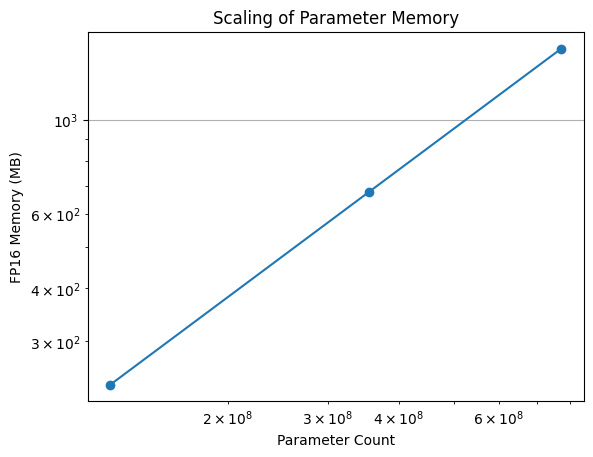

In [ ]:
import matplotlib.pyplot as plt

models_names = ["Small", "Medium", "Large"]

params = [124356864, 354601984, 773615360]

fp16_memory = [
    (p * 2) / (1024**2)
    for p in params
]

plt.figure()

plt.loglog(params, fp16_memory, marker='o')

plt.xlabel("Parameter Count")
plt.ylabel("FP16 Memory (MB)")
plt.title("Scaling of Parameter Memory")

plt.grid(True)

plt.show()

# **Section 3: From CPU to GPU : Inference Profiling & Optimization**

In [ ]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

PyTorch: 2.10.0+cu128
CUDA Available: True
Device: Tesla T4
VRAM: 15.64 GB
name, memory.total [MiB], memory.free [MiB]
Tesla T4, 15360 MiB, 13878 MiB


In [ ]:
!pip install transformers accelerate psutil pynvml

In [ ]:
import torch
import time
import psutil
from transformers import AutoTokenizer, AutoModelForCausalLM



In [ ]:
AutoTokenizer.from_pretrained("gpt2")
tokenizer = AutoTokenizer.from_pretrained("gpt2")

In [ ]:
prompt = "Artificial intelligence is transforming science and engineering. "

prompt = prompt * 40

inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)

print("Tokenized length:", inputs["input_ids"].shape)

Tokenized length: torch.Size([1, 322])


In [ ]:
model = AutoModelForCausalLM.from_pretrained("gpt2")

model = model.to("cpu")

model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
with torch.no_grad():
    for _ in range(2):
        _ = model.generate(**inputs, max_new_tokens=128)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [ ]:
# CPU baseline profiling

process = psutil.Process()

ram_before = process.memory_info().rss / 1e9

start = time.time()

with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=128)

end = time.time()

ram_after = process.memory_info().rss / 1e9

latency = end - start

tokens_generated = outputs.shape[1] - inputs["input_ids"].shape[1]

throughput = tokens_generated / latency

cpu_latency_small = latency
throughput_cpu_small = throughput

print("CPU Latency:", latency)
print("Tokens Generated:", tokens_generated)
print("Throughput (tokens/sec):", throughput)
print("RAM Used (GB):", ram_after - ram_before)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


CPU Latency: 13.594292640686035
Tokens Generated: 128
Throughput (tokens/sec): 9.415716093745978
RAM Used (GB): 0.003956736000000127


In [ ]:
model_medium = AutoModelForCausalLM.from_pretrained("gpt2-medium")

model_medium = model_medium.to("cpu")

model_medium.eval()

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [ ]:
process = psutil.Process()

ram_before = process.memory_info().rss / 1e9

start = time.time()

with torch.no_grad():
    outputs_medium = model_medium.generate(**inputs, max_new_tokens=128)

end = time.time()

ram_after = process.memory_info().rss / 1e9

latency = end - start

tokens_generated = outputs_medium.shape[1] - inputs["input_ids"].shape[1]

throughput = tokens_generated / latency


cpu_latency_medium = latency
throughput_cpu_medium = throughput

print("CPU Latency (GPT2-Medium):", latency)
print("Tokens Generated:", tokens_generated)
print("Throughput (tokens/sec):", throughput)
print("RAM Used (GB):", ram_after - ram_before)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


CPU Latency (GPT2-Medium): 27.64325189590454
Tokens Generated: 128
Throughput (tokens/sec): 4.6304248314202034
RAM Used (GB): 0.138428416


# **Observation:**
Increasing model size significantly increases inference latency and reduces throughput on CPU. GPT-2-Medium, which has nearly three times the parameters of GPT-2, exhibited approximately 2.7× higher latency and significantly lower token generation throughput.

In [ ]:
device = "cuda"

model_gpu = AutoModelForCausalLM.from_pretrained("gpt2")

model_gpu = model_gpu.to(device)

model_gpu.eval()

inputs_gpu = {k: v.to(device) for k, v in inputs.items()}

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# GPU migration
start = time.time()

with torch.no_grad():
    outputs_gpu = model_gpu.generate(**inputs_gpu, max_new_tokens=128)

end = time.time()

latency = end - start

tokens_generated = outputs_gpu.shape[1] - inputs_gpu["input_ids"].shape[1]

throughput = tokens_generated / latency

latency_gpu = latency
throughput_gpu = throughput

print("GPU Latency:", latency)
print("Tokens Generated:", tokens_generated)
print("Throughput (tokens/sec):", throughput)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


GPU Latency: 1.7356488704681396
Tokens Generated: 128
Throughput (tokens/sec): 73.7476353529247


In [ ]:
import pynvml

pynvml.nvmlInit()

handle = pynvml.nvmlDeviceGetHandleByIndex(0)

info = pynvml.nvmlDeviceGetMemoryInfo(handle)

print("GPU Memory Used (GB):", info.used / 1e9)
print("GPU Memory Total (GB):", info.total / 1e9)

GPU Memory Used (GB): 2.0365312
GPU Memory Total (GB): 16.10612736


In [ ]:
# FP16 optimization
model_fp16 = AutoModelForCausalLM.from_pretrained(
    "gpt2",
    torch_dtype=torch.float16
).to("cuda")

model_fp16.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
# FP16 optimization

start = time.time()

with torch.no_grad():
    outputs_fp16 = model_fp16.generate(**inputs_gpu, max_new_tokens=128)

end = time.time()

latency_fp16 = end - start

tokens_generated = outputs_fp16.shape[1] - inputs_gpu["input_ids"].shape[1]

throughput_fp16 = tokens_generated / latency_fp16

latency_fp16 = latency_fp16
throughput_fp16 = throughput_fp16

print("FP16 GPU Latency:", latency_fp16)
print("Tokens Generated:", tokens_generated)
print("FP16 Throughput (tokens/sec):", throughput_fp16)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


FP16 GPU Latency: 1.3021891117095947
Tokens Generated: 128
FP16 Throughput (tokens/sec): 98.29601464871232


In [ ]:
# Batch inference optimization

batch_prompts = [prompt] * 4

# Set the pad token to the end-of-sequence token
tokenizer.pad_token = tokenizer.eos_token

batch_inputs = tokenizer(
    batch_prompts,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=512
)

batch_inputs = {k: v.to("cuda") for k, v in batch_inputs.items()}

In [ ]:
# Batch inference optimization

start = time.time()

with torch.no_grad():
    outputs_batch = model_fp16.generate(**batch_inputs, max_new_tokens=128)

end = time.time()

latency_batch = end - start

tokens_generated = outputs_batch.shape[1] - batch_inputs["input_ids"].shape[1]

total_tokens = tokens_generated * batch_inputs["input_ids"].shape[0]

throughput_batch = total_tokens / latency_batch

latency_batch = latency_batch
throughput_batch = throughput_batch

print("Batch Latency:", latency_batch)
print("Tokens per sequence:", tokens_generated)
print("Total Tokens Generated:", total_tokens)
print("Batch Throughput (tokens/sec):", throughput_batch)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Batch Latency: 1.2119903564453125
Tokens per sequence: 128
Total Tokens Generated: 512
Batch Throughput (tokens/sec): 422.4456055093228


In [ ]:
import pandas as pd

results = {
    "Experiment": [
        "CPU GPT-2",
        "CPU GPT-2-Medium",
        "GPU GPT-2 (FP32)",
        "GPU GPT-2 (FP16)",
        "GPU GPT-2 Batch=4"
    ],
    "Latency (seconds)": [
        cpu_latency_small,
        cpu_latency_medium,
        latency_gpu,
        latency_fp16,
        latency_batch
    ],
    "Throughput (tokens/sec)": [
        throughput_cpu_small,
        throughput_cpu_medium,
        throughput_gpu,
        throughput_fp16,
        throughput_batch
    ]
}

df = pd.DataFrame(results)

print("Final Inference Performance Comparison")
display(df)

Final Inference Performance Comparison


,Experiment,Latency (seconds),Throughput (tokens/sec)
0,CPU GPT-2,13.594293,9.415716
1,CPU GPT-2-Medium,27.643252,4.630425
2,GPU GPT-2 (FP32),1.735649,73.747635
3,GPU GPT-2 (FP16),1.302189,98.296015
4,GPU GPT-2 Batch=4,1.211990,422.445606
